# LAB IA - Gaussian Mixtures con AutoEncoder
En este laboratorio trabajaremos con un **Encoder** para comprimir imágenes en un espacio latente.
Luego, entrenaremos un **Gaussian Mixture Model (GMM)** sobre ese espacio para **generar nuevas imagenes**.

Pasos:
1. Cargar dataset local.
2. Preprocesar imágenes (redimensionar, normalizar).
3. Definir y entrenar AutoEncoder.
4. Extraer embeddings latentes.
5. Ajustar un GMM sobre el espacio latente.
6. Generar imágenes nuevas desde el GMM.


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision

from sklearn.mixture import GaussianMixture


## 1. Dataset personalizado
Se cargan todas las imágenes desde la carpeta `A:/dataResiduos`.
- Se convierten a RGB
- Se redimensionan a 64x64
- Se normalizan en rango [-1, 1]


In [25]:
# Ruta con subcarpetas (clases)
dataDir = r"A:\dataResiduos"

transform = transforms.Compose([
    transforms.Resize((64,64)),       # reescalar imágenes 800x600 → 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset con clases
dataset = datasets.ImageFolder(root=dataDir, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Total imágenes:", len(dataset))
print("Clases detectadas:", dataset.classes)


Total imágenes: 55421
Clases detectadas: ['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella']


## 2. Definir Encoder

El AutoEncoder estará compuesto por:
- **Encoder**: comprime la imagen (64x64x3 → vector latente `z_dim`)
- **Decoder**: reconstruye la imagen desde el vector latente

El tamaño del espacio latente se define con `z_dim = 64`.


In [26]:
z_dim = 64  # tamaño del espacio latente

class Encoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*3, 512),
            nn.ReLU(),
            nn.Linear(512, z_dim)
        )
    def forward(self, x):
        return self.enc(x)

class Decoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.dec = nn.Sequential(
            nn.Linear(z_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 64*64*3),
            nn.Tanh()
        )
    def forward(self, z):
        x_hat = self.dec(z)
        return x_hat.view(-1, 3, 64, 64)

class AutoEncoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

device = "cuda" if torch.cuda.is_available() else "cpu"
autoencoder = AutoEncoder(z_dim).to(device)
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()


## 3. Entrenamiento del Encoder

Entrenamos durante 10 épocas usando:
- Optimizador **Adam**
- Función de pérdida **MSE (Mean Squared Error)**

El objetivo es que la imagen reconstruida sea lo más parecida posible a la original.


In [28]:
epochs = 5
autoencoder.train()

for epoch in range(epochs):
    total_loss = 0
    for imgs, _ in tqdm(dataloader):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        outputs, _ = autoencoder(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(dataloader):.4f}")


100%|██████████| 866/866 [12:44<00:00,  1.13it/s]


Epoch 1/5 - Loss: 0.0671


100%|██████████| 866/866 [06:27<00:00,  2.24it/s]


Epoch 2/5 - Loss: 0.0470


100%|██████████| 866/866 [06:05<00:00,  2.37it/s]


Epoch 3/5 - Loss: 0.0440


100%|██████████| 866/866 [05:55<00:00,  2.44it/s]


Epoch 4/5 - Loss: 0.0426


100%|██████████| 866/866 [06:11<00:00,  2.33it/s]

Epoch 5/5 - Loss: 0.0419


## 4. Extraer Representaciones Latentes

Una vez entrenado el AutoEncoder, usamos el **encoder** para obtener los vectores latentes de todas las imágenes del dataset.  
Estos vectores serán la entrada para el modelo de Gaussian Mixtures.


In [29]:
autoencoder.eval()
latents = []

with torch.no_grad():
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        z = autoencoder.encoder(imgs)
        latents.append(z.cpu().numpy())

latents = np.concatenate(latents, axis=0)
print("Forma de los vectores latentes:", latents.shape)


Forma de los vectores latentes: (55421, 64)


## 5. Ajustar Gaussian Mixture Model (GMM)

Entrenamos un **GMM con 10 componentes** sobre los vectores latentes.  
Cada componente del GMM modela una distribución gaussiana en el espacio latente.


In [30]:
n_components = 10  # número de gaussianas
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(latents)
print("GMM entrenado con", n_components, "componentes")


GMM entrenado con 10 componentes


## 6. Generar Nuevas Imagenes

1. Muestreamos vectores latentes desde el GMM.
2. Pasamos esos vectores al **decoder** del AutoEncoder.
3. Obtenemos imágenes completamente nuevas, similares a las del dataset original.


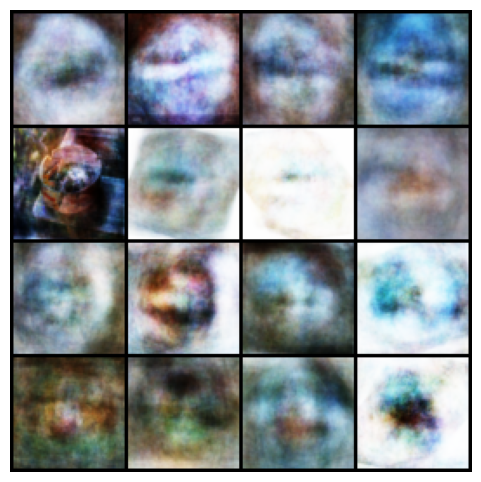

In [31]:
# Muestreamos del GMM
samples, _ = gmm.sample(16)
samples = torch.tensor(samples).float().to(device)

# Decodificamos
with torch.no_grad():
    gen_imgs = autoencoder.decoder(samples).cpu()

# Visualizamos
grid = np.transpose(torchvision.utils.make_grid(gen_imgs, nrow=4, normalize=True), (1,2,0))
plt.figure(figsize=(6,6))
plt.imshow(grid)
plt.axis("off")
plt.show()


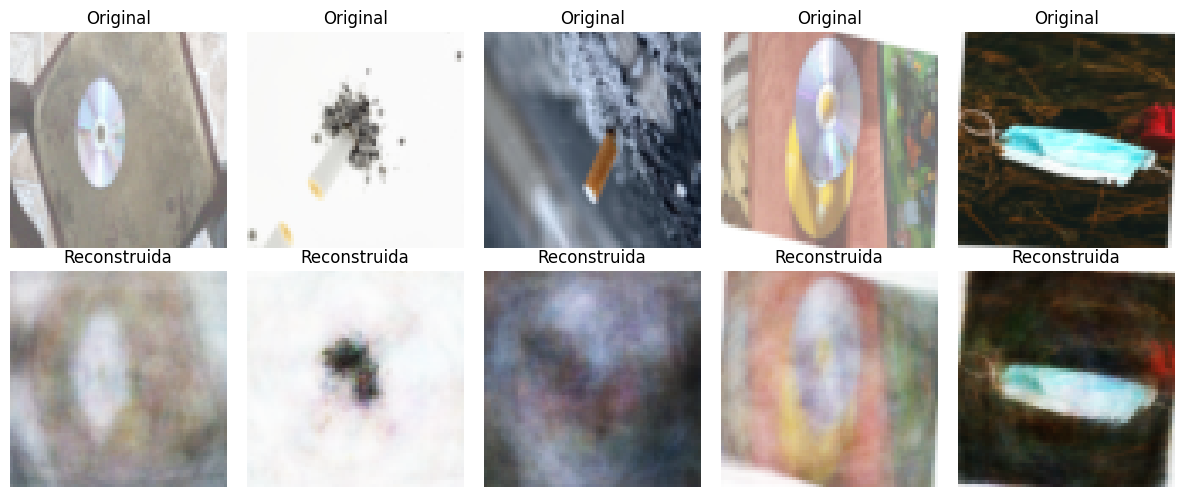

In [33]:
autoencoder.eval()
imgs, _ = next(iter(dataloader))
imgs = imgs.to(device)

with torch.no_grad():
    recon, _ = autoencoder(imgs)

# mostramos las 5 primeras
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i in range(5):
    # originales
    axes[0, i].imshow(np.transpose((imgs[i].cpu()*0.5+0.5).numpy(), (1,2,0)))
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")
    
    # reconstruidas
    axes[1, i].imshow(np.transpose((recon[i].cpu()*0.5+0.5).numpy(), (1,2,0)))
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstruida")

plt.tight_layout()
plt.show()
